In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

from msi.utils import preprocessing, plotting, input_output
from msfm.utils import prior, parameters, files, logger, cross_statistics, scales

24-03-06 02:56:56   imports.py INF   Setting up healpy to run on 256 CPUs 
24-03-06 02:56:58   imports.py INF   Setting up healpy to run on 256 CPUs 


In [9]:
# lensing only
params = ["Om", "s8", "w0", "Aia", "n_Aia"]
with_lensing = True
with_clustering = False
with_cross_z = True
with_cross_probe = False

In [10]:
bin_indices, bin_names = cross_statistics.get_cross_bin_indices(
        with_lensing=with_lensing,
        with_clustering=with_clustering,
        with_cross_z=with_cross_z,
        with_cross_probe=with_cross_probe,
)

In [5]:
base_dir = "/pscratch/sd/a/athomsen/DESY3/v7/linear_bias/cls"

# # 2 Mpc/h
# cl_file = "fiducial_l_mins=[30,30,30,30,30,30,30,30],l_maxs=[1463.8,2145.9,2882.3,3435.4,1463.8,2145.9,2882.3,3435.4],n_bins=33.npy"

# # 4 Mpc/h
# cl_file = "fiducial_l_mins=[30,30,30,30,30,30,30,30],l_maxs=[,731.9,1073.0,1441.2,1717.7,731.9,1073.0,1441.2,1717.7],n_bins=33.npy"

# # 6 Mpc/h
# cl_file = "fiducial_l_mins=[30,30,30,30,30,30,30,30],l_maxs=[,487.9,715.3,960.8,1145.1,487.9,715.3,960.8,1145.1],n_bins=33.npy"

# # 8 Mpc/h
# cl_file = "fiducial_l_mins=[30,30,30,30,30,30,30,30],l_maxs=[366.0,536.5,720.6,858.9,366.0,536.5,720.6,858.9],n_bins=33.npy"

# 10 Mpc/h
cl_file = "fiducial_l_mins=[30,30,30,30,30,30,30,30],l_maxs=[292.8,429.2,576.5,687.1,292.8,429.2,576.5,687.1],n_bins=33.npy"

# 20 Mpc/h
cl_file = "fiducial_l_mins=[30,30,30,30,30,30,30,30],l_maxs=[146.4,214.6,288.2,343.5,146.4,214.6,288.2,343.5],n_bins=33.npy"

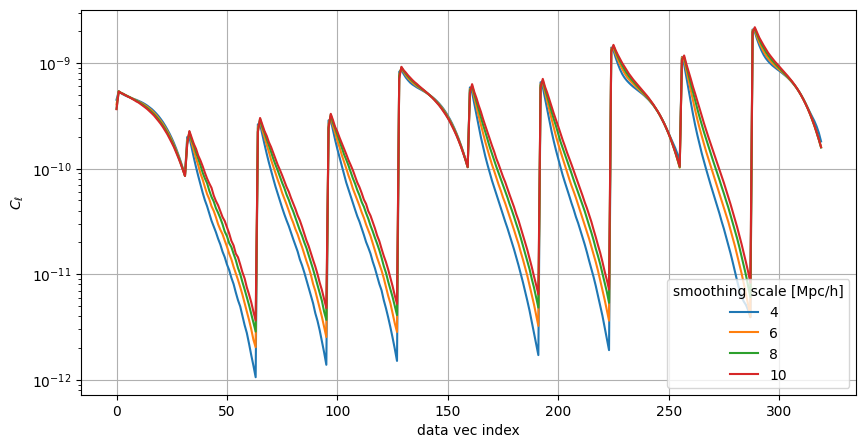

In [27]:
cl_files = [
    # "fiducial_l_mins=[30,30,30,30,30,30,30,30],l_maxs=[1463.8,2145.9,2882.3,3435.4,1463.8,2145.9,2882.3,3435.4],n_bins=33.npy",
    "fiducial_l_mins=[30,30,30,30,30,30,30,30],l_maxs=[,731.9,1073.0,1441.2,1717.7,731.9,1073.0,1441.2,1717.7],n_bins=33.npy",
    "fiducial_l_mins=[30,30,30,30,30,30,30,30],l_maxs=[,487.9,715.3,960.8,1145.1,487.9,715.3,960.8,1145.1],n_bins=33.npy",
    "fiducial_l_mins=[30,30,30,30,30,30,30,30],l_maxs=[366.0,536.5,720.6,858.9,366.0,536.5,720.6,858.9],n_bins=33.npy",
    "fiducial_l_mins=[30,30,30,30,30,30,30,30],l_maxs=[292.8,429.2,576.5,687.1,292.8,429.2,576.5,687.1],n_bins=33.npy",
    # "fiducial_l_mins=[30,30,30,30,30,30,30,30],l_maxs=[146.4,214.6,288.2,343.5,146.4,214.6,288.2,343.5],n_bins=33.npy",
]
# fwhms = [2, 4, 6, 8, 10, 20]
# fwhms = [2, 4, 6, 8, 10, 20]
fwhms = [4, 6, 8, 10, 20]

n_files = len(cl_files)

# fig, ax = plt.subplots(figsize=(10,5*n_files), nrows=n_files, sharex=True, sharey=True)
fig, ax = plt.subplots(figsize=(10,5), sharex=True, sharey=True)


for i, cl_file in enumerate(cl_files):
    binned_cls = np.load(os.path.join(base_dir, cl_file))
    
    binned_cls = binned_cls[...,bin_indices]
    # binned_cls = binned_cls[...,0]

    binned_cls = np.mean(binned_cls, axis=0)
    binned_cls = np.concatenate([binned_cls[..., i] for i in range(binned_cls.shape[-1])], axis=-1)
    
    ax.plot(binned_cls, label=fwhms[i])
    
ax.set(xscale="linear", yscale="log", xlabel="data vec index", ylabel=r"$C_\ell$")
ax.legend(title="smoothing scale [Mpc/h]")
ax.grid(True)
